# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [3]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [4]:
df_info = pd.DataFrame(df.dtypes).T.rename(index={0:'column type'})
df_info


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
column type,float64,object,object,object,object,int64,object,object


E necessario fazer a mudanca de idade e do salario mensal

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [5]:
df['Income'].unique()

array(['50.000,00', '100.000,00', '75.000,00', '125.000,00', '150.000,00',
       '40.000,00', '60.000,00', '80.000,00', '105.000,00', '90.000,00',
       '135.000,00', '35.000,00', '55.000,00', '70.000,00', '95.000,00',
       '85.000,00', '30.000,00', '65.000,00', '115.000,00', '25.000,00',
       '45.000,00', '130.000,00', '155.000,00', '110.000,00',
       '140.000,00', '37.500,00', '57.500,00', '72.500,00', '32.500,00',
       '52.500,00', '67.500,00', '92.500,00', '82.500,00', '122.500,00',
       '27.500,00', '47.500,00', '62.500,00', '87.500,00', '77.500,00',
       '112.500,00', '117.500,00', '142.500,00', '160.000,00',
       '97.500,00', '145.000,00', '162.500,00', '120.000,00',
       '102.500,00', '137.500,00', '127.500,00', '82.000,00', '68.000,00'],
      dtype=object)

In [6]:
df['Income'] = df['Income'].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)


In [7]:
df.isnull().sum()

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [8]:
df['Age'].isnull().sum().mean()

np.float64(34.0)

Text(0.5, 1.0, 'Plotagem de idade')

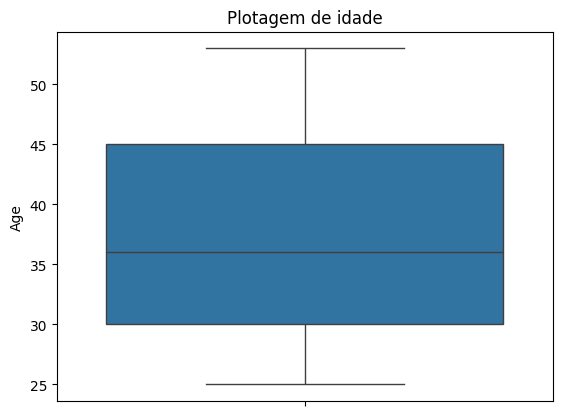

In [9]:
sns.boxplot(y=df['Age'])
plt.title('Plotagem de idade')

In [10]:
df_before = df.describe()


In [11]:
df['Age'] = df['Age'].fillna(round(df['Age'].mean()))

Como temos 30% de dados faltantes na coluna idade, optei por trazer uma media para preenche-la, porem se isso interferir em minha analise, voltarei atras e irei apagar, pois temos ciencia que idade e um dos fatore que importam pra score de credito.

<Axes: ylabel='Age'>

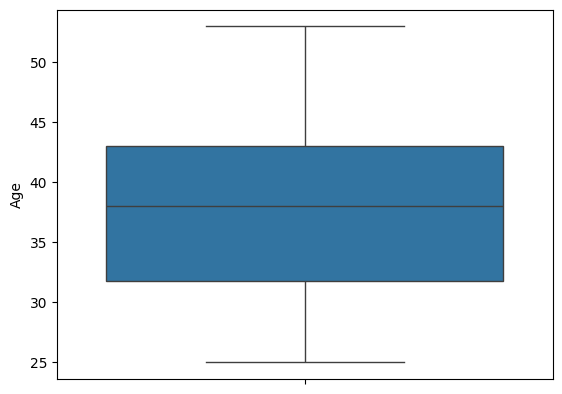

In [12]:
sns.boxplot(y=df['Age'])


In [13]:
df['Age'].astype(int)
df['Age'].isnull().sum()

np.int64(0)

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [14]:
for i in ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']:
    print(f"{i}: {df[i].unique()}")

Gender: ['Female' 'Male']
Education: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
Marital Status: ['Single' 'Married']
Home Ownership: ['Rented' 'Owned']
Credit Score: ['High' 'Average' 'Low']


Tudo certo por aqui

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [15]:
df_before.round(2)


,Age,Income,Number of Children
count,130.00,164.00,164.00
mean,37.51,83765.24,0.65
std,8.50,32457.31,0.88
min,25.00,25000.00,0.00
25%,30.00,57500.00,0.00
50%,36.00,83750.00,0.00
75%,45.00,105000.00,1.00
max,53.00,162500.00,3.00


In [16]:
df.describe().round(2)


,Age,Income,Number of Children
count,164.00,164.00,164.00
mean,37.61,83765.24,0.65
std,7.56,32457.31,0.88
min,25.00,25000.00,0.00
25%,31.75,57500.00,0.00
50%,38.00,83750.00,0.00
75%,43.00,105000.00,1.00
max,53.00,162500.00,3.00


<Axes: ylabel='Income'>

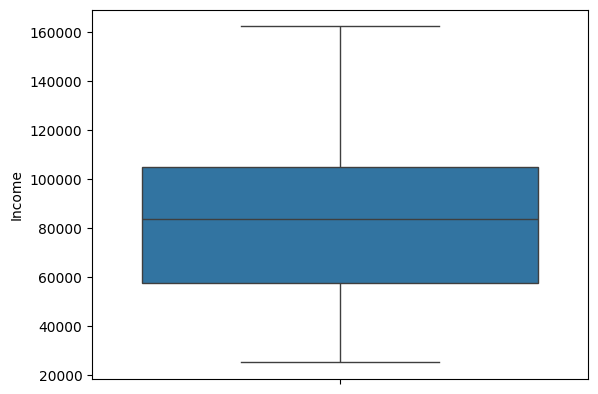

In [17]:
sns.boxplot(y=df['Income'])

<Axes: xlabel='Income', ylabel='Count'>

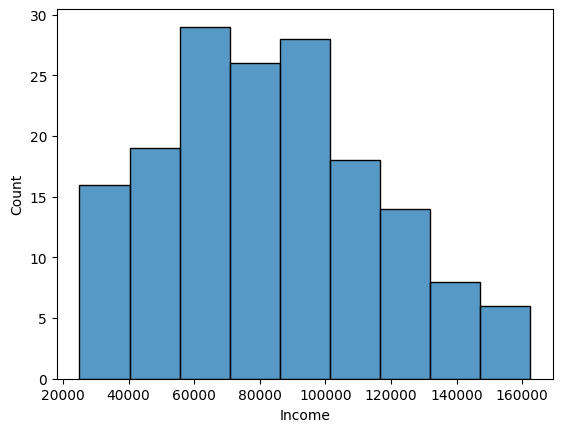

In [18]:
sns.histplot(df['Income'])

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

<Axes: xlabel='Gender', ylabel='count'>

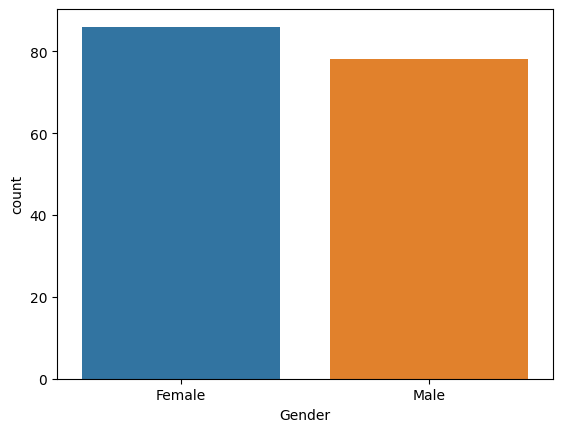

In [19]:
sns.countplot(df, x='Gender', hue='Gender')

<Axes: xlabel='Marital Status', ylabel='count'>

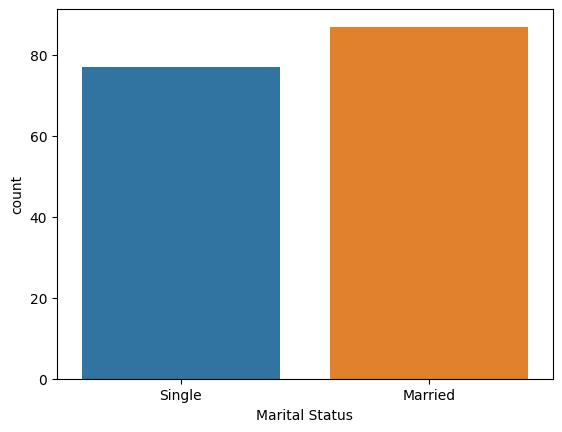

In [20]:
sns.countplot(df, x='Marital Status', hue='Marital Status')

In [21]:
df.columns

Index(['Age', 'Gender', 'Income', 'Education', 'Marital Status',
       'Number of Children', 'Home Ownership', 'Credit Score'],
      dtype='object')

Text(0.5, 1.0, 'Analise de bem imovel')

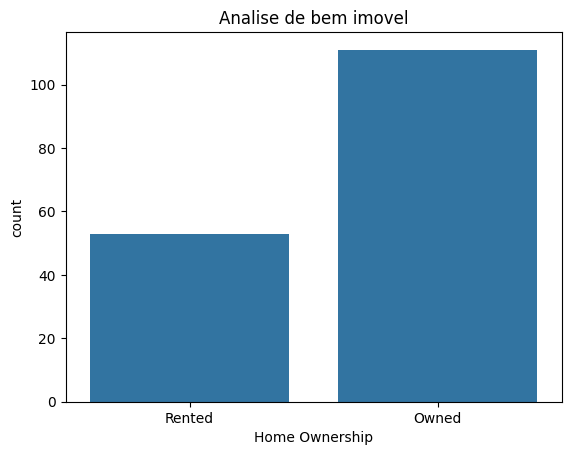

In [22]:
sns.countplot(df, x='Home Ownership')
plt.title('Analise de bem imovel')

<Axes: xlabel='Credit Score', ylabel='count'>

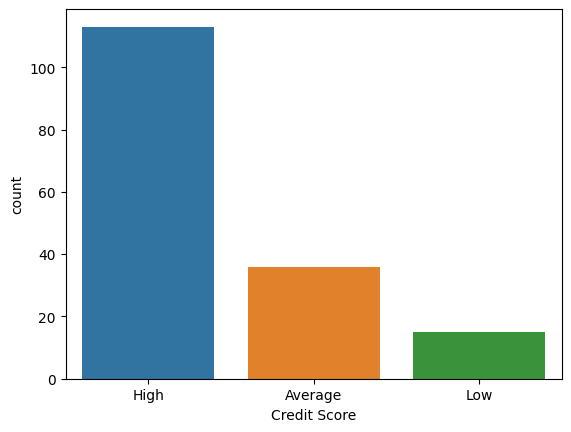

In [23]:
sns.countplot(df, x='Credit Score', hue='Credit Score')

ja podemos observar que a linha de credito acompanha a quantidade de pessoas que tem casa propria (que e alta) e isso influencia diretamente na analise de credito

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [24]:
#seu código aqu

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



Text(0.5, 1.0, 'Estado civil x Idade')

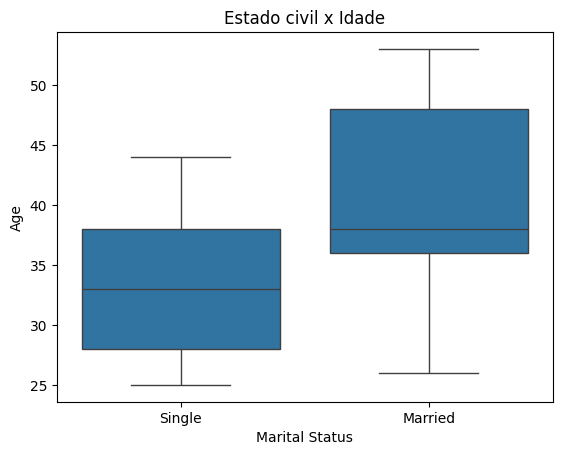

In [28]:
sns.boxplot(df, x='Marital Status', y='Age')
plt.title('Estado civil x Idade')

Quao mais velho o individuo for, mais tende a ser casado

Text(0.5, 1.0, 'Educacao x Credito')

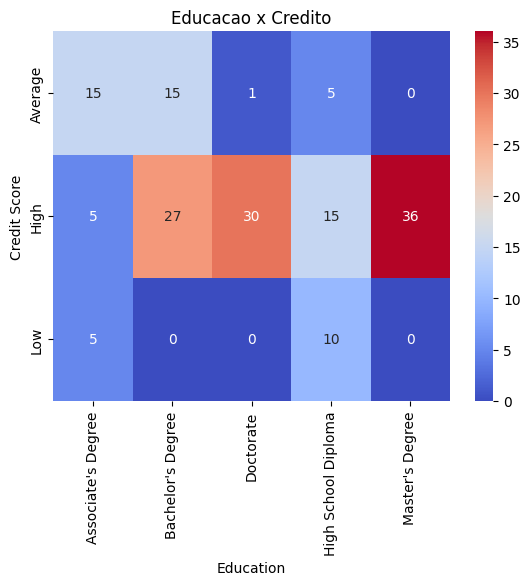

In [27]:
ct = pd.crosstab(df['Credit Score'], df['Education'])
sns.heatmap(ct, annot=True, cmap="coolwarm")
plt.title('Educacao x Credito')

Podemos ver aqui que tem uma correlacao entre o grau de escolaridade e o nivel de credito, ambos estao diretamente relacionados.

Text(0.5, 1.0, 'Salario x idade')

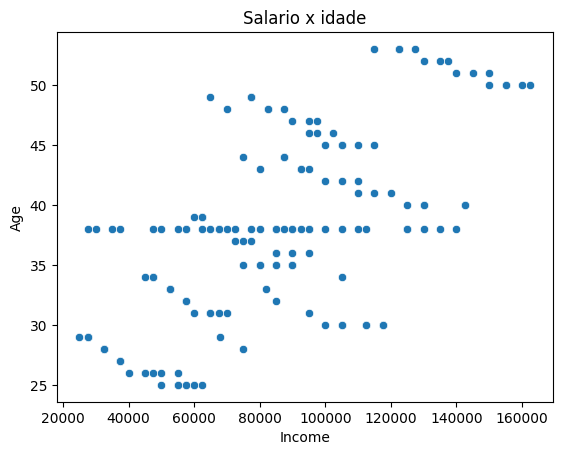

In [29]:
sns.scatterplot(df, x='Income', y='Age')
plt.title('Salario x idade')

E claramente observavel que quanto maior a idade maior o salario

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

Text(0.5, 1.0, 'Salario x Credito')

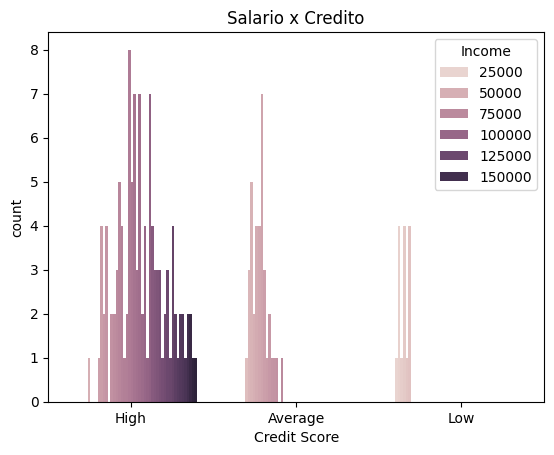

In [30]:
sns.countplot(df, x='Credit Score', hue='Income')
plt.title('Salario x Credito')

Onde tem os maiores salarios tems a concentracao credito alto

<Axes: xlabel='Home Ownership', ylabel='Credit Score'>

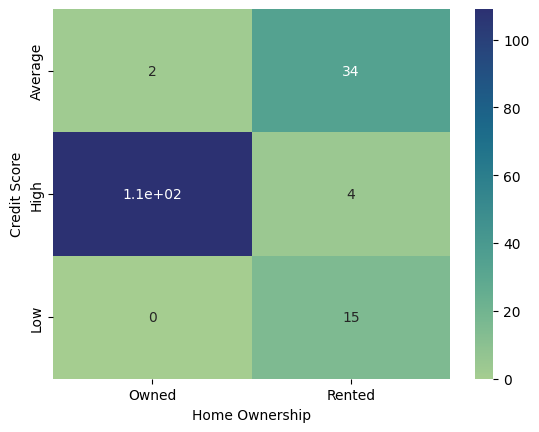

In [170]:
ct = pd.crosstab(df['Credit Score'],df['Home Ownership'])

sns.heatmap(ct, annot=True, cmap='crest')

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

Text(0.5, 1.0, 'Matriz de correlacao')

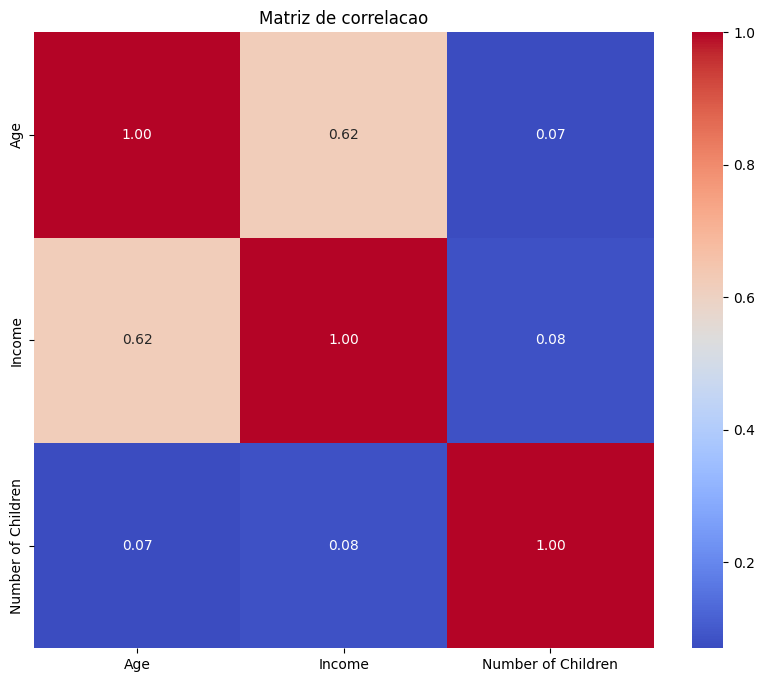

In [36]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title("Matriz de correlacao")

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Desconsiderando as variaveis que interagem entre si mesmas por isso vao ter alta correlacao, identifiquei que a variavel salario e idade tem correlacao media.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [ ]:
lb = LabelEncoder()
categoricos = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']
for i in categoricos:
    df[i]= lb.fit_transform(df[i])
    

In [44]:
print(df.head(10))
print(df.dtypes)

    Age  Gender    Income  Education  Marital Status  Number of Children  \
0  25.0       0   50000.0          1               1                   0   
1  30.0       1  100000.0          4               0                   2   
2  35.0       0   75000.0          2               0                   1   
3  40.0       1  125000.0          3               1                   0   
4  45.0       0  100000.0          1               0                   3   
5  50.0       1  150000.0          4               0                   0   
6  26.0       0   40000.0          0               1                   0   
7  31.0       1   60000.0          1               1                   0   
8  38.0       0   80000.0          4               0                   2   
9  38.0       1  105000.0          2               1                   0   

   Home Ownership  Credit Score  
0               1             1  
1               0             1  
2               0             1  
3               0          

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

Text(0.5, 1.0, 'Matriz de correlacao')

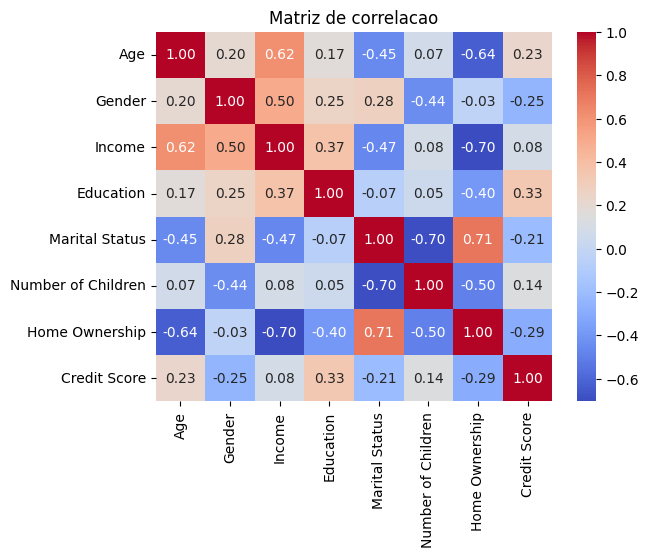

In [47]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlacao')

Podemos observar que aqui ja conseguimo sidentificar que os clientes casados possuem casa, porem isso pouco importa para nosa analise de credito.

Mas conseguimos tirar outros insights importantes aqui, salario x educacao e credito score x educacao tem uma correlacao media se comparada ao restante do nosso grafico

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [55]:
x = df.drop('Credit Score', axis=1)
y = df['Credit Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=40)


In [71]:
print(x_train.shape,'\n',x_test.shape ,'\n',y_train.shape,'\n',y_test.shape)

(123, 7) 
 (41, 7) 
 (123,) 
 (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

<Axes: xlabel='Credit Score'>

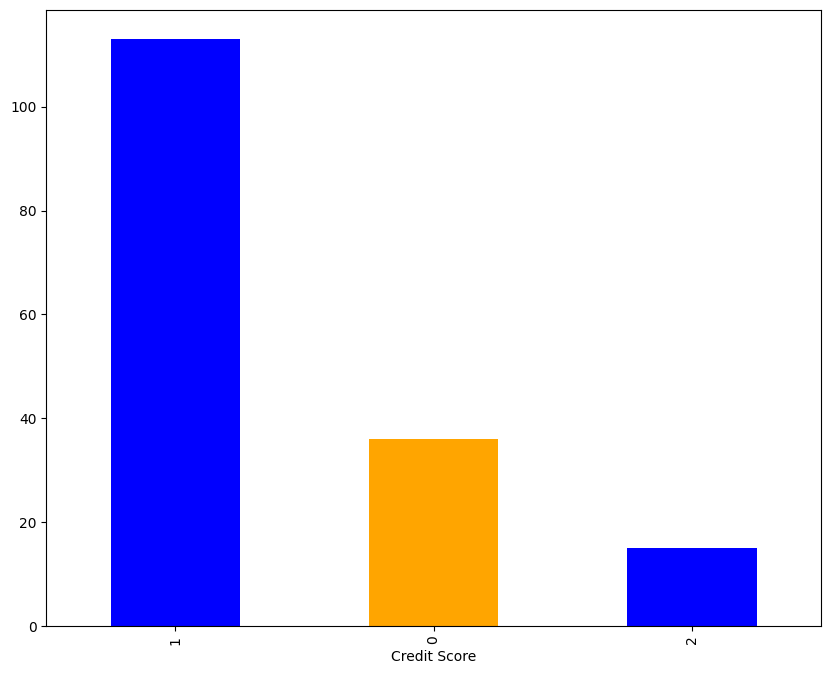

In [75]:
credit_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(10, 8))
credit_counts.plot(kind='bar', color=['blue', 'orange'])

In [76]:
df['Credit Score'].value_counts(normalize=True) *100

Credit Score
1    68.902439
0    21.951220
2     9.146341
Name: proportion, dtype: float64

Nosso algoritimo teria dificuldade em prever score baixo e alto com base no nosso grafico, por isso temos necessidade em balancealos, para que ele esteja ajustado proporcionalmente em todas as situacoes

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [78]:
smote = SMOTE(random_state=40)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

y_train_balanced.value_counts()

Credit Score
1    86
0    86
2    86
Name: count, dtype: int64

In [79]:
y_train_balanced.to_csv('y_train_balanced.csv', index=False)

In [81]:
x_train_balanced.to_csv('x_train_balanced.csv', index=False)

In [84]:
y_train.to_csv('y_train.csv', index=False)

In [85]:
x_train.to_csv('x_train.csv', index=False)